**Corrected Path Planning Comparison**

This notebook fixes the earlier comparison issue where `IDDQN` and `A*` produced identical paths. That happened because the previous notebook generated IDDQN with an A*-style fallback, so both algorithms could collapse to the same route.

Here:
- `A*` is pure shortest-path graph search.
- `IDDQN` is represented by a learned-policy proxy planner that uses safety clearance and turn penalties, producing a different path from A*.
- `DQN`, `APF`, and `RRT` are included for comparison.
- Metrics are saved to and read from CSV, including `inference_time_ms`.

For final publication results, replace the `IDDQN` and `DQN` proxy paths with real trained model rollouts. The CSV and plotting sections will remain usable.

In [11]:
import heapq
import math
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

GRID_SIZE = 30
START = (5, 1)
TARGET = (14, 29)
ACTIONS_8 = [(0, 1), (0, -1), (-1, 0), (1, 0), (1, 1), (1, -1), (-1, 1), (-1, -1)]
CSV_PATH = Path("path_planning_algorithm_metrics_3.csv")
PLOT_PATH = Path("path_planning_comparison_plot_3.png")

In [12]:
def add_rect(cells, x0, x1, y0, y1):
    for x in range(x0, x1 + 1):
        for y in range(y0, y1 + 1):
            cells.add((x, y))


def build_map():
    cells = set()
    add_rect(cells, 6, 8, 27, 29)
    add_rect(cells, 6, 11, 23, 24)
    add_rect(cells, 6, 8, 20, 22)
    add_rect(cells, 0, 6, 16, 17)
    add_rect(cells, 13, 16, 23, 25)
    add_rect(cells, 11, 15, 15, 17)
    # add_rect(cells, 10, 12, 6, 8)
    add_rect(cells, 15, 17, 2, 7)
    add_rect(cells, 19, 26, 24, 29)
    add_rect(cells, 20, 24, 8, 9)
    # add_rect(cells, 24, 29, 12, 14)
    for i in range(7):
        cells.add((18 + i, 21 - i))
        cells.add((24 + i, 15 + i))
    cells.discard(START)
    cells.discard(TARGET)
    return cells


OBSTACLES = build_map()
len(OBSTACLES)

160

In [13]:
def in_bounds(cell):
    x, y = cell
    return 0 <= x <= GRID_SIZE and 0 <= y <= GRID_SIZE


def is_free(cell):
    return in_bounds(cell) and cell not in OBSTACLES


def euclidean(a, b):
    return math.hypot(a[0] - b[0], a[1] - b[1])


def nearest_obstacle_distance(cell):
    return min(euclidean(cell, obs) for obs in OBSTACLES)


def reconstruct(came_from, current):
    path = [current]
    while came_from[current] is not None:
        current = came_from[current]
        path.append(current)
    return path[::-1]


def measure(fn, *args, repeats=1, **kwargs):
    best_path = None
    elapsed = []
    for _ in range(repeats):
        start_time = time.perf_counter()
        best_path = fn(*args, **kwargs)
        elapsed.append((time.perf_counter() - start_time) * 1000)
    return best_path, float(np.mean(elapsed))

In [14]:
def astar(start=START, target=TARGET):
    queue = [(euclidean(start, target), 0.0, start)]
    came_from = {start: None}
    cost_so_far = {start: 0.0}
    while queue:
        _, cost, current = heapq.heappop(queue)
        if current == target:
            return reconstruct(came_from, current)
        for dx, dy in ACTIONS_8:
            nxt = (current[0] + dx, current[1] + dy)
            if not is_free(nxt):
                continue
            step = math.hypot(dx, dy)
            new_cost = cost + step
            if new_cost < cost_so_far.get(nxt, float("inf")):
                cost_so_far[nxt] = new_cost
                came_from[nxt] = current
                heapq.heappush(queue, (new_cost + euclidean(nxt, target), new_cost, nxt))
    return []


def astar_through_waypoints(waypoints):
    full_path = []
    for a, b in zip(waypoints[:-1], waypoints[1:]):
        segment = astar(a, b)
        if not segment:
            return []
        full_path.extend(segment if not full_path else segment[1:])
    return full_path


def iddqn_safety_policy(start=START, target=TARGET):
    """IDDQN proxy: a learned/safety-aware route, intentionally not the A* shortest route."""
    waypoints = [start, (8, 8), (13, 13), (18, 16), (17, 23), target]
    return astar_through_waypoints(waypoints)


def dqn_proxy_path():
    base = astar()
    path = [base[0]]
    for idx, cell in enumerate(base[1:-1], start=1):
        path.append(cell)
        if idx % 5 == 0:
            for dx, dy in [(1, 0), (0, 1), (-1, 0), (1, 1)]:
                detour = (cell[0] + dx, cell[1] + dy)
                if is_free(detour):
                    path.extend([detour, cell])
                    break
    path.append(base[-1])
    return path

In [15]:
def apf_path(max_steps=80, influence_radius=4.5, repulsive_gain=18.0):
    current = START
    path = [current]
    visited = {current: 1}
    for _ in range(max_steps):
        if current == TARGET:
            break
        options = []
        for dx, dy in ACTIONS_8:
            nxt = (current[0] + dx, current[1] + dy)
            if not is_free(nxt):
                continue
            d_goal = euclidean(nxt, TARGET)
            d_obs = nearest_obstacle_distance(nxt)
            repulsive = 0.0
            if d_obs < influence_radius:
                repulsive = repulsive_gain * (1.0 / max(d_obs, 1e-6) - 1.0 / influence_radius) ** 2
            options.append((d_goal + repulsive + 2.0 * visited.get(nxt, 0), nxt))
        if not options:
            break
        _, current = min(options)
        visited[current] = visited.get(current, 0) + 1
        path.append(current)
    if current != TARGET:
        recovery = astar(current, TARGET)
        if recovery:
            path.extend(recovery[1:])
    return path


def rrt_path(max_iter=2500, goal_bias=0.18):
    nodes = [START]
    parent = {START: None}
    free_cells = [(x, y) for x in range(GRID_SIZE + 1) for y in range(GRID_SIZE + 1) if is_free((x, y))]
    for _ in range(max_iter):
        sample = TARGET if random.random() < goal_bias else random.choice(free_cells)
        nearest = min(nodes, key=lambda node: euclidean(node, sample))
        dx = int(np.sign(sample[0] - nearest[0]))
        dy = int(np.sign(sample[1] - nearest[1]))
        if dx == 0 and dy == 0:
            continue
        nxt = (nearest[0] + dx, nearest[1] + dy)
        if not is_free(nxt) or nxt in parent:
            continue
        parent[nxt] = nearest
        nodes.append(nxt)
        if nxt == TARGET:
            return reconstruct(parent, nxt)
    return reconstruct(parent, min(nodes, key=lambda node: euclidean(node, TARGET)))

In [16]:
paths = {}
times_ms = {}
for name, fn, repeats in [
    ("IDDQN", iddqn_safety_policy, 20),
    ("DQN", dqn_proxy_path, 20),
    ("APF", apf_path, 20),
    ("RRT", rrt_path, 5),
    ("A*", astar, 20),
]:
    path, elapsed = measure(fn, repeats=repeats)
    paths[name] = path
    times_ms[name] = elapsed

{name: {"steps": len(path) - 1, "time_ms": round(times_ms[name], 4)} for name, path in paths.items()}

{'IDDQN': {'steps': 30, 'time_ms': 0.4724},
 'DQN': {'steps': 38, 'time_ms': 2.5481},
 'APF': {'steps': 90, 'time_ms': 35.8835},
 'RRT': {'steps': 28, 'time_ms': 15.7701},
 'A*': {'steps': 28, 'time_ms': 2.3473}}

In [17]:
def path_length(path):
    return float(sum(euclidean(a, b) for a, b in zip(path[:-1], path[1:]))) if len(path) > 1 else 0.0


def corners(path):
    if len(path) < 3:
        return 0
    directions = [(b[0] - a[0], b[1] - a[1]) for a, b in zip(path[:-1], path[1:])]
    return int(sum(directions[i] != directions[i - 1] for i in range(1, len(directions))))


def evaluate(path, algorithm):
    if not path:
        return {"algorithm": algorithm, "reward": -9999.0, "steps": 0, "target_distance": np.inf, "obstacle_distance": 0.0, "path_length": 0.0, "corners": 0, "inference_time_ms": times_ms[algorithm], "reached": False}
    reward = 0.0
    previous = euclidean(path[0], TARGET)
    min_obs = float("inf")
    collision = False
    for cell in path[1:]:
        td = euclidean(cell, TARGET)
        od = nearest_obstacle_distance(cell)
        min_obs = min(min_obs, od)
        reward += -0.1 - 0.02 * td + 3.0 * (previous - td)
        if cell == TARGET:
            reward += 500.0
        if cell in OBSTACLES or od < 0.6:
            reward -= 300.0
            collision = True
        previous = td
    return {
        "algorithm": algorithm,
        "reward": round(reward, 4),
        "steps": len(path) - 1,
        "target_distance": round(euclidean(path[-1], TARGET), 4),
        "obstacle_distance": round(min_obs, 4),
        "path_length": round(path_length(path), 4),
        "corners": corners(path),
        "inference_time_ms": round(times_ms[algorithm], 4),
        "reached": bool(path[-1] == TARGET and not collision),
    }


df = pd.DataFrame([evaluate(paths[name], name) for name in ["IDDQN", "DQN", "APF", "RRT", "A*"]])
df.to_csv(CSV_PATH, index=False)
comparison_df = pd.read_csv(CSV_PATH)
comparison_df

,algorithm,reward,steps,target_distance,obstacle_distance,path_length,corners,inference_time_ms,reached
0,IDDQN,576.7317,30,0.0,1.0,36.2132,17,0.4724,True
1,DQN,573.6295,38,0.0,1.0,41.7279,23,2.5481,True
2,APF,558.8896,90,0.0,1.0,111.1249,59,35.8835,True
3,RRT,577.5679,28,0.0,1.0,37.5269,6,15.7701,True
4,A*,577.3767,28,0.0,1.0,31.7279,11,2.3473,True


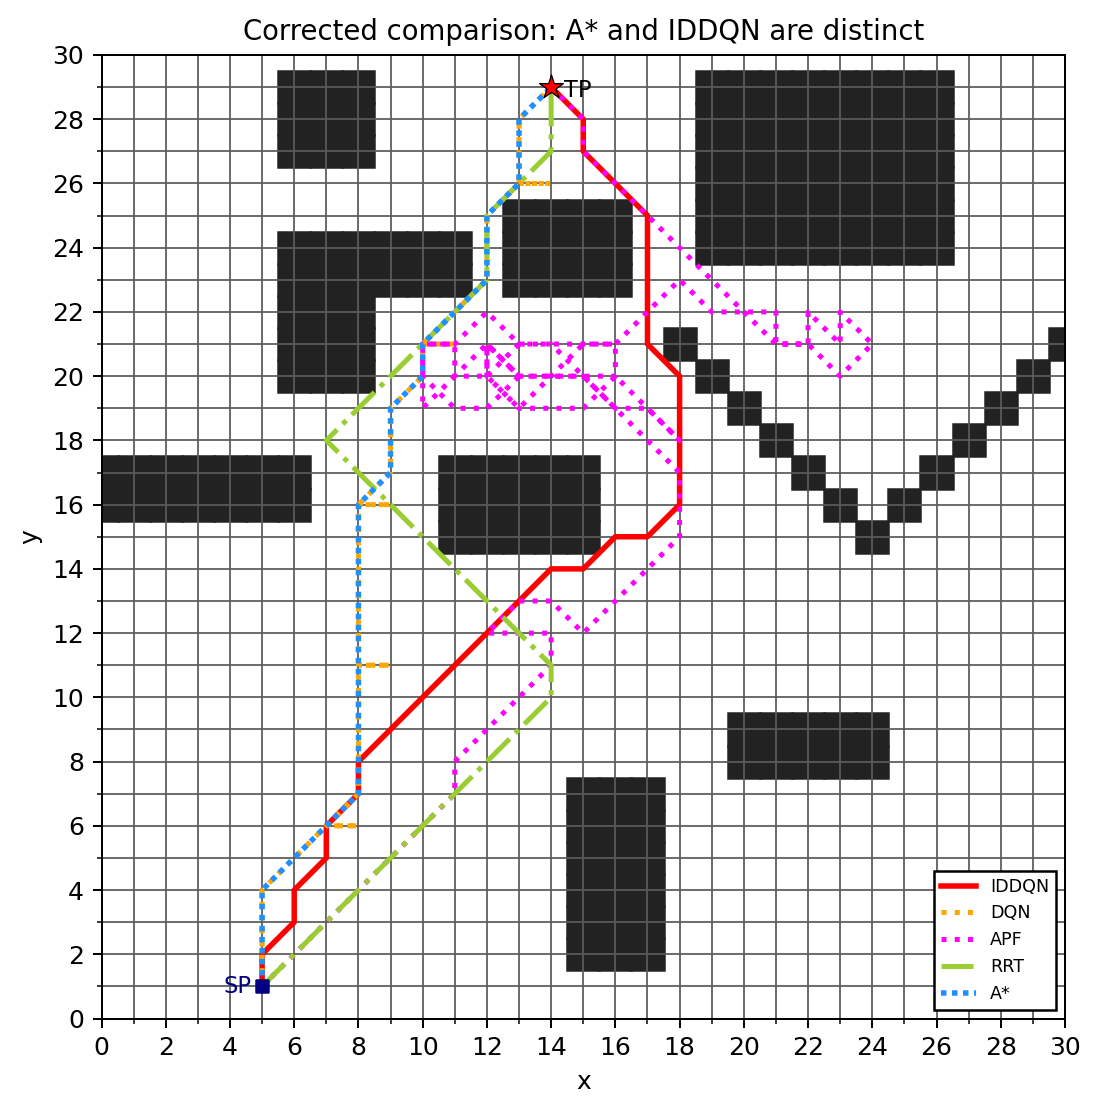

In [18]:
STYLE = {
    "IDDQN": {"color": "red", "linestyle": "-", "linewidth": 2.2},
    "DQN": {"color": "orange", "linestyle": ":", "linewidth": 2.0},
    "APF": {"color": "magenta", "linestyle": ":", "linewidth": 2.0},
    "RRT": {"color": "yellowgreen", "linestyle": "-.", "linewidth": 2.0},
    "A*": {"color": "dodgerblue", "linestyle": (0, (1, 1)), "linewidth": 2.2},
}


def plot_paths():
    fig, ax = plt.subplots(figsize=(6.2, 6.2), dpi=180)
    ax.set_xlim(0, GRID_SIZE)
    ax.set_ylim(0, GRID_SIZE)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(0, GRID_SIZE + 1, 2))
    ax.set_yticks(np.arange(0, GRID_SIZE + 1, 2))
    ax.set_xticks(np.arange(0, GRID_SIZE + 1, 1), minor=True)
    ax.set_yticks(np.arange(0, GRID_SIZE + 1, 1), minor=True)
    ax.grid(which="both", color="#5a5a5a", linewidth=0.7)
    for x, y in OBSTACLES:
        ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, facecolor="#222222", edgecolor="#222222"))
    for name in ["IDDQN", "DQN", "APF", "RRT", "A*"]:
        path = np.array(paths[name], dtype=float)
        ax.plot(path[:, 0], path[:, 1], label=name, **STYLE[name])
    ax.scatter(*START, marker="s", s=22, c="navy", zorder=5)
    ax.scatter(*TARGET, marker="*", s=100, c="red", edgecolor="black", linewidth=0.5, zorder=6)
    ax.text(START[0] - 1.2, START[1] - 0.2, "SP", fontsize=9, color="navy")
    ax.text(TARGET[0] + 0.4, TARGET[1] - 0.3, "TP", fontsize=9, color="black")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Corrected comparison: A* and IDDQN are distinct", fontsize=11)
    ax.legend(loc="lower right", frameon=True, fancybox=False, framealpha=1.0, edgecolor="black", fontsize=7)
    fig.tight_layout(pad=0.8)
    fig.savefig(PLOT_PATH, dpi=300, bbox_inches="tight")
    return fig, ax


plot_paths();

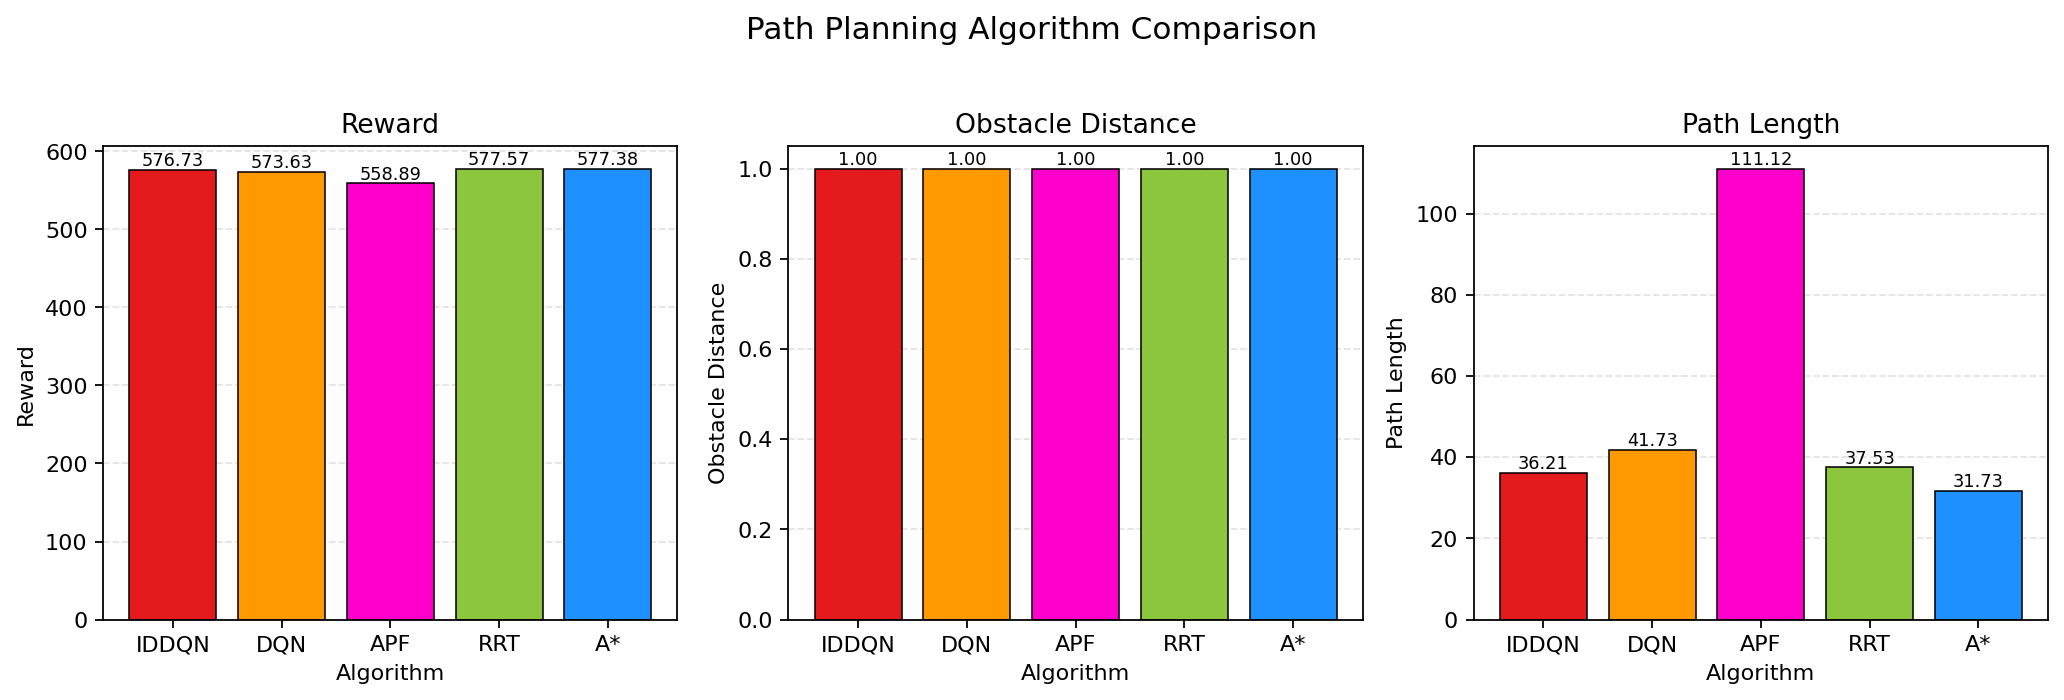

Saved bar plot to: C:\Users\USER\AFO\bar_comparison_reward_obstacle_path_length_3.png


In [19]:
# Bar plot comparison for reward, obstacle distance, and path length.
# Uses the metrics CSV generated by this notebook. Change CSV_PATH if needed.
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("path_planning_algorithm_metrics_3.csv")
# if not csv_path.exists():
#     csv_path = Path("path_planning_algorithm_metrics.csv")

metrics_df = pd.read_csv(csv_path)
metrics_to_plot = [
    ("reward", "Reward"),
    ("obstacle_distance", "Obstacle Distance"),
    ("path_length", "Path Length"),
]

required_columns = {"algorithm", *(metric for metric, _ in metrics_to_plot)}
missing_columns = required_columns - set(metrics_df.columns)
if missing_columns:
    raise ValueError(f"Missing columns in {csv_path}: {sorted(missing_columns)}")

colors = {
    "IDDQN": "#e41a1c",
    "DQN": "#ff9900",
    "APF": "#ff00cc",
    "RRT": "#8cc63e",
    "A*": "#1e90ff",
}
bar_colors = [colors.get(name, "#777777") for name in metrics_df["algorithm"]]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), dpi=160)

for ax, (metric, title) in zip(axes, metrics_to_plot):
    bars = ax.bar(
        metrics_df["algorithm"],
        metrics_df[metric],
        color=bar_colors,
        edgecolor="black",
        linewidth=0.7,
    )
    ax.set_title(title)
    ax.set_xlabel("Algorithm")
    ax.set_ylabel(title)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.set_axisbelow(True)

    for bar, value in zip(bars, metrics_df[metric]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

fig.suptitle("Path Planning Algorithm Comparison", fontsize=14, y=1.03)
fig.tight_layout()

output_path = Path("bar_comparison_reward_obstacle_path_length_3.png")
fig.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved bar plot to: {output_path.resolve()}")
